1. Import the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

2. Upload Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


3. Load the Dataset

In [4]:
print(uploaded.keys())

dict_keys(['heart.csv'])


4. Display the Dataset

In [5]:
import pandas as pd

df = pd.read_csv("heart.csv")

print("Heart Disease Dataset Shape:", df.shape)

Heart Disease Dataset Shape: (1025, 14)


5. Check Dataset Information

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


6. Check Missing Values

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


7. Remove Missing Values

In [8]:
df = df.dropna()

print("Dataset Shape After Removing Missing Values:", df.shape)

Dataset Shape After Removing Missing Values: (1025, 14)


8. Check Heart Disease Distribution

In [9]:
print(df["target"].value_counts())

target
1    526
0    499
Name: count, dtype: int64


9. Visualize Heart Disease Distribution

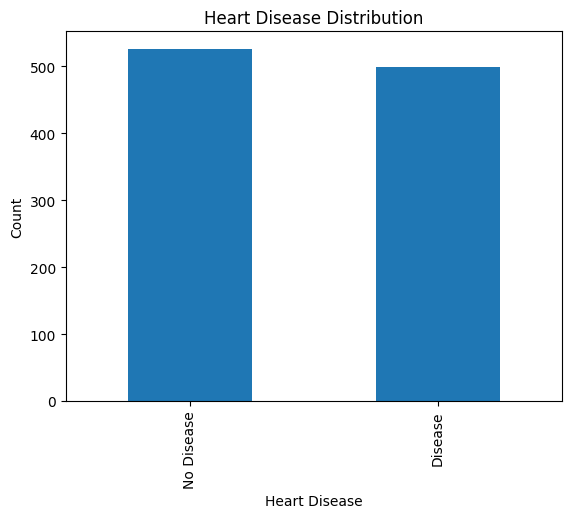

In [10]:
df["target"].value_counts().plot(kind="bar")

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Distribution")
plt.show()

10. Feature Correlation

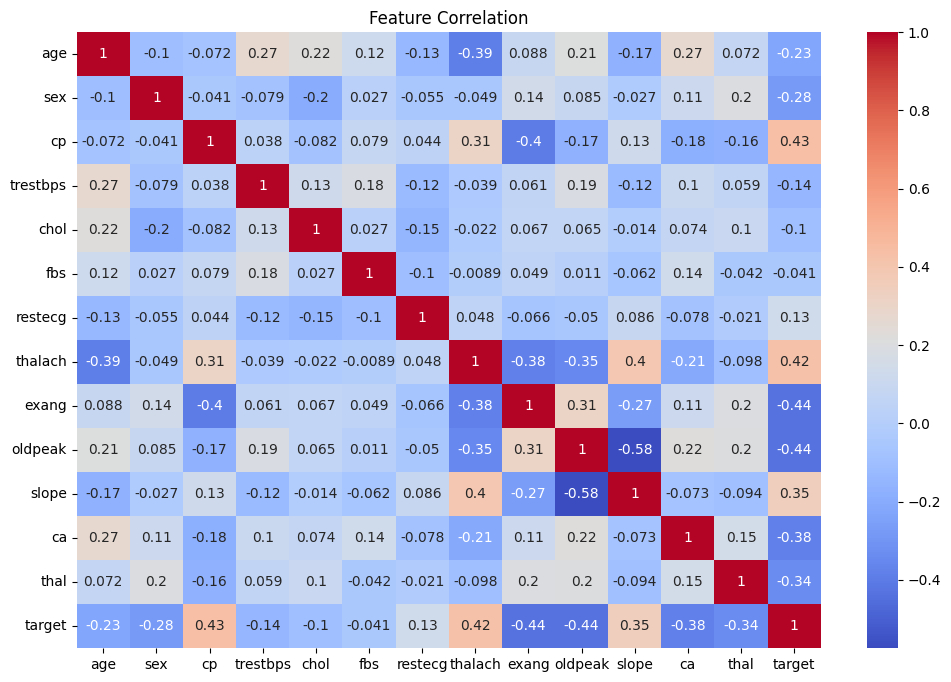

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

11. Split Input and Output

In [12]:
X = df.drop("target", axis=1)
y = df["target"]

print("Input Features:")
print(X.head())

print("Target:")
print(y.head())

Input Features:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  
0   2     3  
1   0     3  
2   0     3  
3   1     3  
4   3     2  
Target:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


12. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


13. Train Decision Tree Model

In [14]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


14. Make Predictions

In [15]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 0 0 1 1 1 0]


15. Calculate Accuracy

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 87.3170731707317 %


16. Classification Report

In [17]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.89      0.85      0.87       100
     Disease       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



17. Confusion Matrix

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[85 15]
 [11 94]]


18. Visualize Confusion Matrix

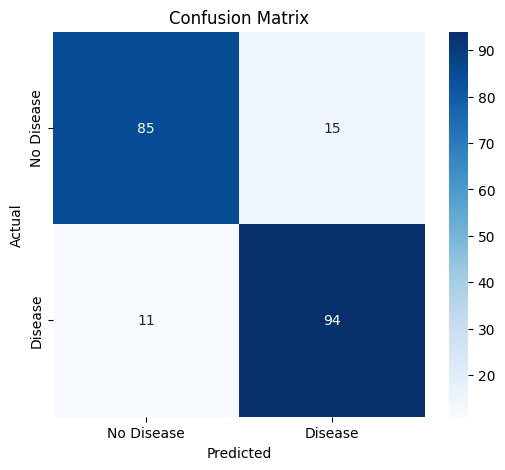

In [19]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

19. Decision Tree Visualization

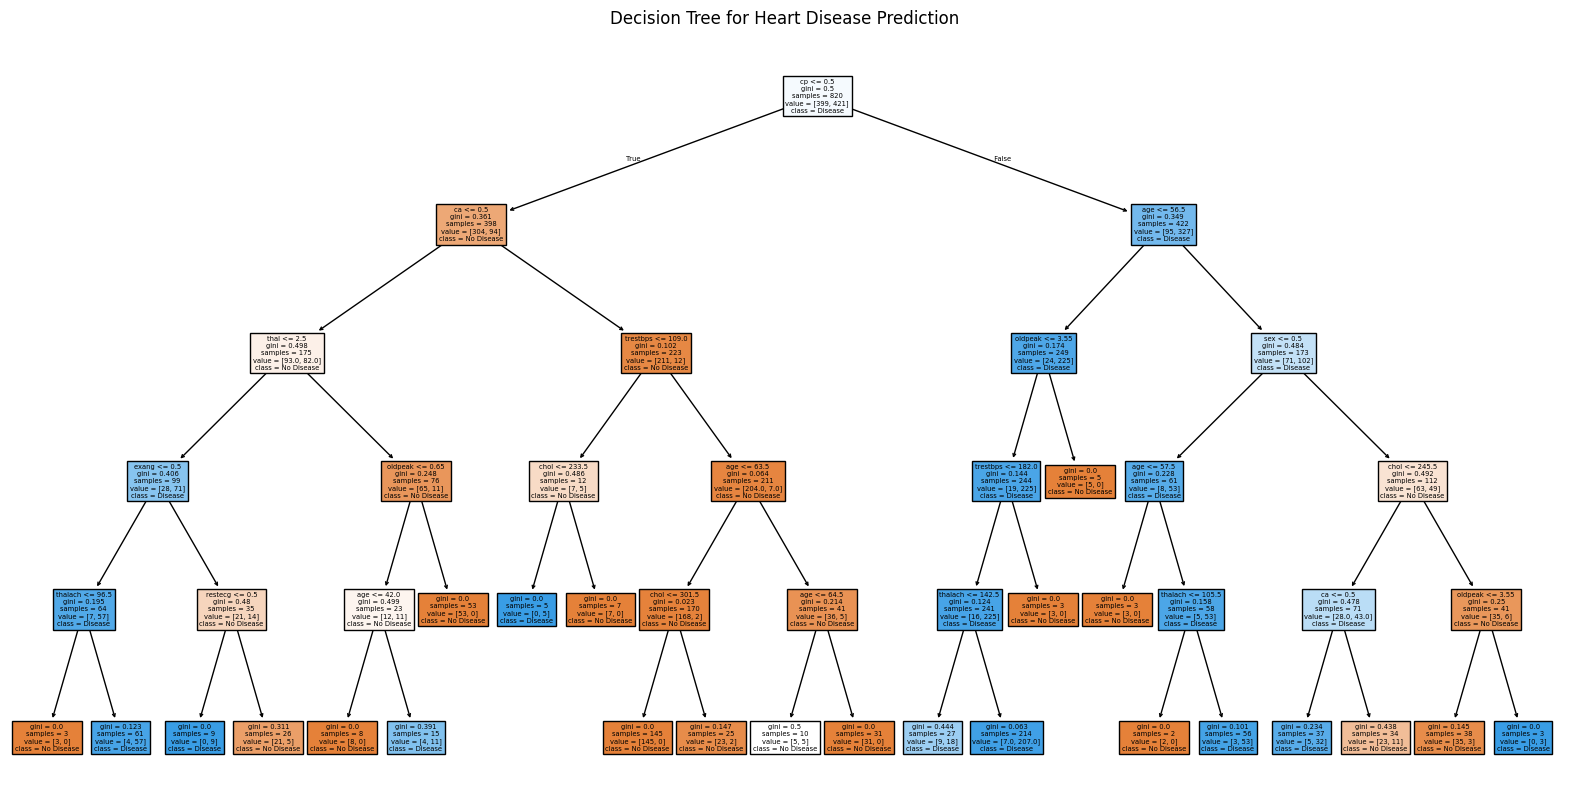

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)

plt.title("Decision Tree for Heart Disease Prediction")
plt.show()

20. Feature Importance

In [21]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
cp          0.372280
ca          0.138164
age         0.109885
thal        0.088238
oldpeak     0.063845
chol        0.053462
sex         0.046021
thalach     0.040041
exang       0.034112
restecg     0.027317
trestbps    0.026634
fbs         0.000000
slope       0.000000
dtype: float64


21. Visualize Feature Importance

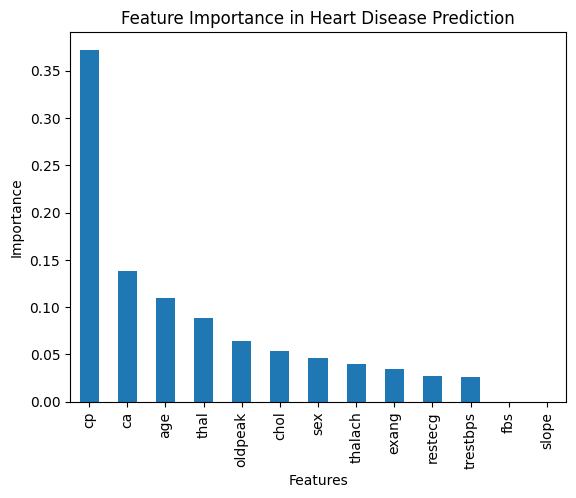

In [22]:
importance.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Heart Disease Prediction")
plt.show()

22. Create Prediction Function

In [23]:
def predict_heart_disease(patient_data):

    prediction = model.predict([patient_data])

    if prediction[0] == 0:
        return "NO HEART DISEASE"
    else:
        return "HEART DISEASE"

23. Check Input Feature Order

In [24]:
print(X.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


24. Predict Heart Disease for a New Patient

In [25]:
patient = [
    52,    # age
    1,     # sex
    0,     # cp
    125,   # trestbps
    212,   # chol
    0,     # fbs
    1,     # restecg
    168,   # thalach
    0,     # exang
    1.0,   # oldpeak
    2,     # slope
    0,     # ca
    2      # thal
]

result = predict_heart_disease(patient)

print("Prediction:", result)

Prediction: HEART DISEASE


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
